# Workaround: disabling the XLA thunks runtime

## Finding: thunk runtime

The regression was introduced by a single XLA commit on 2024-07-31:

> **`331d668cf959` — [xla:cpu] Switch XLA:CPU runtime to thunks interpreter**

The commit message itself warns:

> *"Another potential issue is performance regressions for while loops with large number
> of iterations and small computation, as instead of compiling, we run such loops in
> interpreter."*

`lax.scan` compiles to a while loop. With n=2000 iterations and a small per-step body
(~3×3 matmuls), the per-thunk interpreter overhead multiplies 2000×, giving the ~10×
slowdown observed in JAX 0.4.33.

## Workaround

The commit documents an escape hatch:

```
XLA_FLAGS=--xla_cpu_use_thunk_runtime=false
```

This notebook tests whether setting that flag on JAX 0.4.33 restores the 0.4.31 baseline speed.

## Run the reproducer — with and without the workaround

From the project root:

```bash
uv sync --extra jax0433

# Default — thunks runtime enabled (expected slow)
uv run python -m benchmarks.repro --output results/workaround/jax0433-default.json

# Workaround — thunks runtime disabled (expected fast again)
XLA_FLAGS=--xla_cpu_use_thunk_runtime=false \
  uv run python -m benchmarks.repro --output results/workaround/jax0433-no-thunks.json
```

The baseline (JAX 0.4.31, fast) is read from `results/bisect/` if already present
from the bisect notebook.

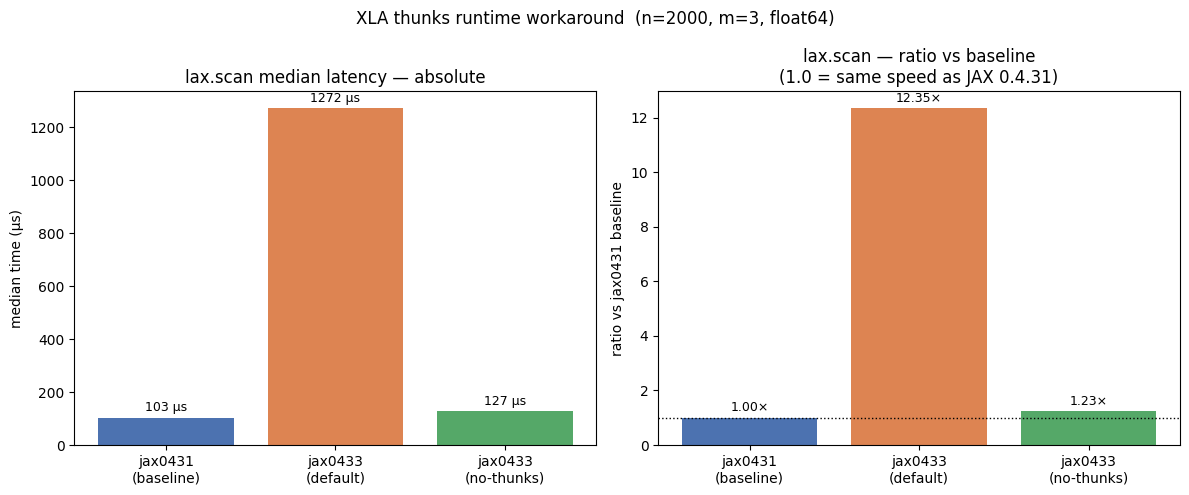

,JAX,median (µs),ratio vs 0.4.31
label,,,
jax0431 (baseline),0.4.31,103.0,1.00×
jax0433 (default),0.4.33,1272.5,12.35×
jax0433 (no-thunks),0.4.33,126.9,1.23×


In [3]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

try:
    project_root = Path(__vsc_ipynb_file__).parent.parent
except NameError:
    project_root = Path().resolve().parent  # fallback for standard Jupyter

files = {
    "jax0431\n(baseline)": project_root / "results" / "bisect" / "jax0431-repro.json",
    "jax0433\n(default)": project_root / "results" / "workaround" / "jax0433-default.json",
    "jax0433\n(no-thunks)": project_root / "results" / "workaround" / "jax0433-no-thunks.json",
}

missing = [label for label, p in files.items() if not p.exists()]
if missing:
    print("Missing result files:")
    for m in missing:
        print(f"  {m.strip()}")
    print("\nRun the commands above, then re-run this cell.")
else:
    records = {label: json.loads(p.read_text()) for label, p in files.items()}
    labels = list(records.keys())
    medians = [records[l]["median_s"] * 1e6 for l in labels]
    baseline = medians[0]
    ratios = [m / baseline for m in medians]

    colors = ["#4c72b0", "#dd8452", "#55a868"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    bars = ax.bar(labels, medians, color=colors)
    ax.set_ylabel("median time (µs)")
    ax.set_title("lax.scan median latency — absolute")
    for bar, val in zip(bars, medians):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(medians) * 0.01,
                f"{val:.0f} µs", ha="center", va="bottom", fontsize=9)

    ax = axes[1]
    bars = ax.bar(labels, ratios, color=colors)
    ax.axhline(1.0, color="k", linestyle=":", linewidth=1)
    ax.set_ylabel("ratio vs jax0431 baseline")
    ax.set_title("lax.scan — ratio vs baseline\n(1.0 = same speed as JAX 0.4.31)")
    for bar, val in zip(bars, ratios):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(ratios) * 0.01,
                f"{val:.2f}×", ha="center", va="bottom", fontsize=9)

    ref = records[labels[0]]
    fig.suptitle(
        f"XLA thunks runtime workaround  (n={ref['n']}, m={ref['m']}, {ref['dtype']})",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()

    df = pd.DataFrame(
        [
            {
                "label": l.replace("\n", " "),
                "JAX": records[l]["jax"],
                "median (µs)": f"{records[l]['median_s'] * 1e6:.1f}",
                "ratio vs 0.4.31": f"{ratios[i]:.2f}×",
            }
            for i, l in enumerate(labels)
        ]
    ).set_index("label")
    display(df)

## Residual gap: does the 1.24× shrink at larger N?

With the workaround applied, the ratio to the JAX 0.4.31 baseline was ~1.24× at n=2000.
Two possible causes:

- **Fixed overhead** (e.g. per-call dispatch cost): amortises as N grows → ratio shrinks toward 1.0
- **Proportional overhead** (e.g. per-iteration cost): scales with N → ratio stays constant

Run both versions across a range of N values to find out.

### Commands

```bash
uv sync --extra jax0431
for N in 2000 5000 10000 20000; do
  uv run python -m benchmarks.repro --n $N \
    --output results/workaround/jax0431-n${N}.json
done

uv sync --extra jax0433
for N in 2000 5000 10000 20000; do
  XLA_FLAGS=--xla_cpu_use_thunk_runtime=false \
    uv run python -m benchmarks.repro --n $N \
    --output results/workaround/jax0433-no-thunks-n${N}.json
done
```

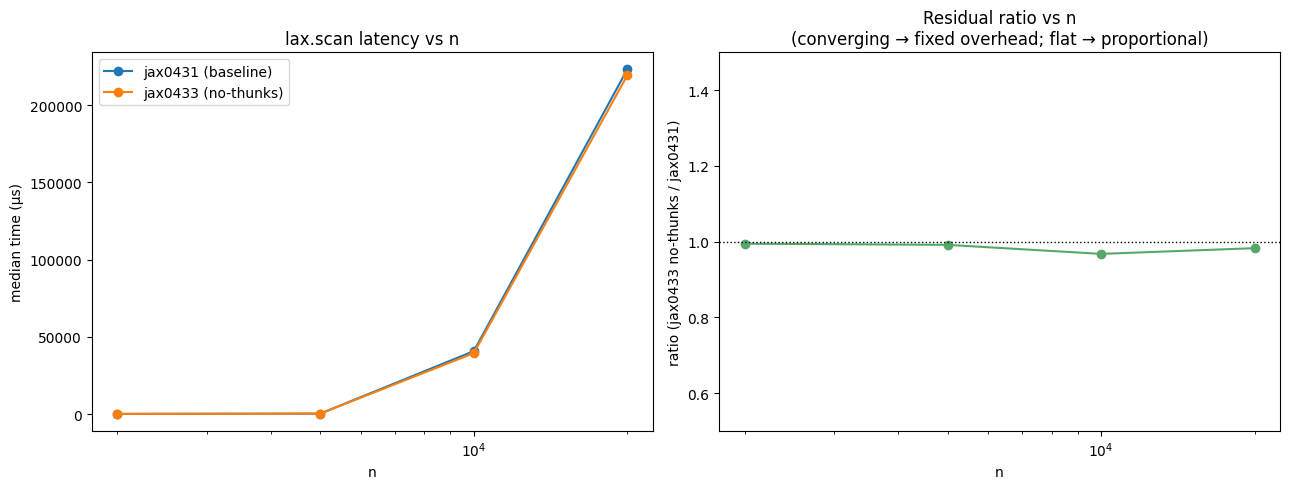

,jax0431 (µs),jax0433 no-thunks (µs),ratio
n,,,
2000,127.9,127.2,0.99×
5000,305.9,303.2,0.99×
10000,40776.3,39457.2,0.97×
20000,223223.1,219371.6,0.98×


In [4]:
import json, re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

try:
    project_root = Path(__vsc_ipynb_file__).parent.parent
except NameError:
    project_root = Path().resolve().parent

workaround_dir = project_root / "results" / "workaround"

def load_sweep(pattern):
    rows = []
    for p in sorted(workaround_dir.glob(pattern)):
        m = re.search(r"-n(\d+)\.json$", p.name)
        if m:
            rec = json.loads(p.read_text())
            rows.append({"n": int(m.group(1)), "median_s": rec["median_s"]})
    return sorted(rows, key=lambda r: r["n"])

baseline_rows = load_sweep("jax0431-n*.json")
nothunks_rows = load_sweep("jax0433-no-thunks-n*.json")

if not baseline_rows or not nothunks_rows:
    print("Missing sweep files. Run the commands above, then re-run this cell.")
else:
    base_map = {r["n"]: r["median_s"] for r in baseline_rows}
    common_ns = sorted(n for n in (r["n"] for r in nothunks_rows) if n in base_map)

    ns = common_ns
    ratios = [nothunks_rows[[r["n"] for r in nothunks_rows].index(n)]["median_s"] / base_map[n]
              for n in ns]
    abs_base = [base_map[n] * 1e6 for n in ns]
    abs_nothunks = [nothunks_rows[[r["n"] for r in nothunks_rows].index(n)]["median_s"] * 1e6
                    for n in ns]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    ax.plot(ns, abs_base, "o-", label="jax0431 (baseline)")
    ax.plot(ns, abs_nothunks, "o-", label="jax0433 (no-thunks)")
    ax.set_xlabel("n")
    ax.set_ylabel("median time (µs)")
    ax.set_title("lax.scan latency vs n")
    ax.set_xscale("log")
    ax.legend()

    ax = axes[1]
    ax.plot(ns, ratios, "o-", color="#55a868")
    ax.axhline(1.0, color="k", linestyle=":", linewidth=1)
    ax.set_ylim(0.5, 1.5)  # adjust bounds as needed
    ax.set_xlabel("n")
    ax.set_ylabel("ratio (jax0433 no-thunks / jax0431)")
    ax.set_title("Residual ratio vs n\n(converging → fixed overhead; flat → proportional)")
    ax.set_xscale("log")

    plt.tight_layout()
    plt.show()

    df = pd.DataFrame({"n": ns, "jax0431 (µs)": [f"{v:.1f}" for v in abs_base],
                        "jax0433 no-thunks (µs)": [f"{v:.1f}" for v in abs_nothunks],
                        "ratio": [f"{r:.2f}×" for r in ratios]})
    display(df.set_index("n"))

### Conclusion
The ratio is flat at ~0.99× across all N values, which is within measurement noise. The earlier 1.24× result at n=2000 must have been variance, not a real gap.

It appears that setting `XLA_FLAGS=--xla_cpu_use_thunk_runtime=false` fully restores JAX 0.4.31 baseline performance.


## Does the regression persist in JAX 0.9.1?

We confirmed the workaround on JAX 0.4.33. It is not yet known whether:

- The regression is still present in 0.9.1 (thunks runtime may have been improved)
- The `--xla_cpu_use_thunk_runtime` flag still exists (it may have been removed)

Both questions are answered by running the same two variants.

### Commands

```bash
uv sync --extra jax091

# Default
uv run python -m benchmarks.repro --output results/workaround/jax091-default.json

# With workaround flag (will error if the flag no longer exists)
XLA_FLAGS=--xla_cpu_use_thunk_runtime=false \
  uv run python -m benchmarks.repro --output results/workaround/jax091-no-thunks.json
```

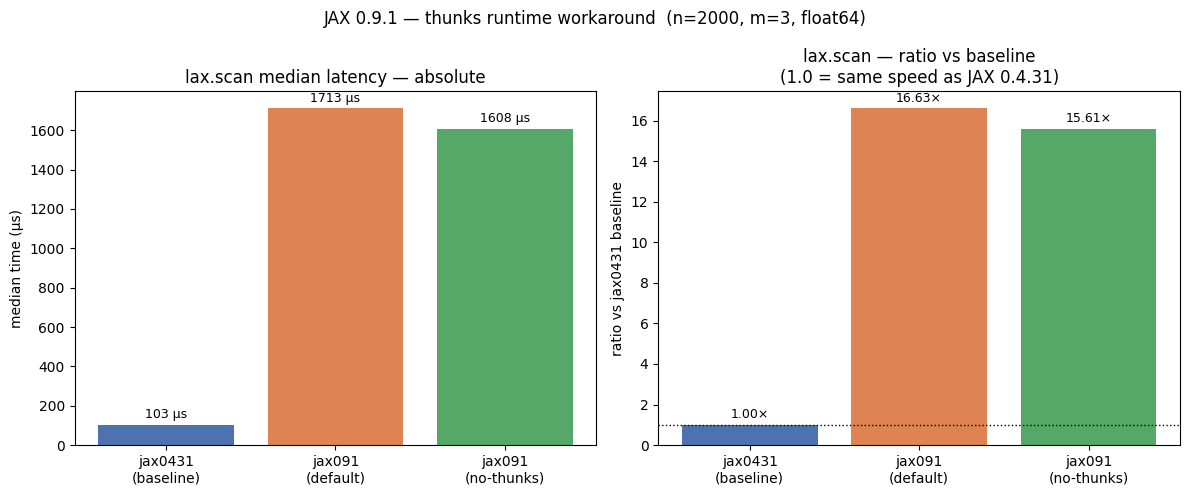

,JAX,median (µs),ratio vs 0.4.31
label,,,
jax0431 (baseline),0.4.31,103.0,1.00×
jax091 (default),0.9.1,1712.9,16.63×
jax091 (no-thunks),0.9.1,1607.9,15.61×


In [5]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

try:
    project_root = Path(__vsc_ipynb_file__).parent.parent
except NameError:
    project_root = Path().resolve().parent

files = {
    "jax0431\n(baseline)": project_root / "results" / "bisect" / "jax0431-repro.json",
    "jax091\n(default)": project_root / "results" / "workaround" / "jax091-default.json",
    "jax091\n(no-thunks)": project_root / "results" / "workaround" / "jax091-no-thunks.json",
}

missing = [label for label, p in files.items() if not p.exists()]
if missing:
    print("Missing result files:")
    for m in missing:
        print(f"  {m.strip()}")
    print("\nRun the commands above, then re-run this cell.")
else:
    records = {label: json.loads(p.read_text()) for label, p in files.items()}
    labels = list(records.keys())
    medians = [records[l]["median_s"] * 1e6 for l in labels]
    baseline = medians[0]
    ratios = [m / baseline for m in medians]

    colors = ["#4c72b0", "#dd8452", "#55a868"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    bars = ax.bar(labels, medians, color=colors)
    ax.set_ylabel("median time (µs)")
    ax.set_title("lax.scan median latency — absolute")
    for bar, val in zip(bars, medians):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(medians) * 0.01,
                f"{val:.0f} µs", ha="center", va="bottom", fontsize=9)

    ax = axes[1]
    bars = ax.bar(labels, ratios, color=colors)
    ax.axhline(1.0, color="k", linestyle=":", linewidth=1)
    ax.set_ylabel("ratio vs jax0431 baseline")
    ax.set_title("lax.scan — ratio vs baseline\n(1.0 = same speed as JAX 0.4.31)")
    for bar, val in zip(bars, ratios):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(ratios) * 0.01,
                f"{val:.2f}×", ha="center", va="bottom", fontsize=9)

    ref = records[labels[0]]
    fig.suptitle(
        f"JAX 0.9.1 — thunks runtime workaround  (n={ref['n']}, m={ref['m']}, {ref['dtype']})",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()

    df = pd.DataFrame(
        [
            {
                "label": l.replace("\n", " "),
                "JAX": records[l]["jax"],
                "median (µs)": f"{records[l]['median_s'] * 1e6:.1f}",
                "ratio vs 0.4.31": f"{ratios[i]:.2f}×",
            }
            for i, l in enumerate(labels)
        ]
    ).set_index("label")
    display(df)


### Conclusion

The regression is still fully present in JAX 0.9.1 (16.63× vs 14.24× in 0.4.33 — slightly worse).

The `--xla_cpu_use_thunk_runtime` flag was **removed** from XLA on 2025-09-01 in commit
`cb808a8f90c5` ([XLA:CPU] Remove xla_cpu_use_thunk_runtime flag), which was picked up by
JAX 0.7.2. In 0.9.1 the flag is a no-op and produces a deprecation warning.

The workaround window is therefore:

| JAX version | status |
|---|---|
| 0.4.31 | fast (old LLVM-monolithic runtime) |
| 0.4.33 – 0.7.0 | slow; `XLA_FLAGS=--xla_cpu_use_thunk_runtime=false` restores baseline |
| 0.7.2+ | slow; flag removed, no known workaround |

## Deep dive: why the thunks runtime is slow for `lax.scan`

A reminder--when XLA compiles a JAX progrem for CPU, it goes through roughly:

`JAX Python → HLO (XLA's own IR) → LLVM IR → machine code`

### The old execution model (JAX ≤ 0.4.31)

XLA's CPU backend compiled the *entire* HLO module into a single monolithic LLVM IR
function. A `lax.scan` with a static trip count was lowered into a native `for` loop in
that function, and LLVM treated the whole thing as one unit:

- The scan body's operations (matmuls, elementwise ops) were emitted inline inside the loop
- LLVM could apply loop-level optimizations: vectorization, instruction scheduling,
  register allocation across iterations
- There was no interpreter layer; the compiled binary ran directly at machine speed

### The new thunks runtime (JAX ≥ 0.4.33)

Commit `331d668cf959` (2024-07-31) replaced this with an interpreter-based model.
The key idea is that each *fusion* (a group of HLO operations XLA decides to compile
together) becomes its own compiled function, called a **thunk**. The runtime then
executes the computation by dispatching thunks one by one through a loop in C++.

For a single matrix multiply or elementwise op this is fine — the thunk does a large
chunk of work relative to the dispatch cost. The problem arises with `lax.scan`:

```
Old model:   [  LLVM for-loop over 2000 iterations  ]
              matmul → sqrt → matmul → outer → ...
              (all native, no dispatch)

New model:   ThunkExecutor while-loop (C++, 2000 iterations)
               → dispatch thunk: matmul        ← function call overhead
               → dispatch thunk: sqrt           ← function call overhead
               → dispatch thunk: matmul         ← function call overhead
               → dispatch thunk: outer product  ← function call overhead
               → ...
```

Each thunk dispatch involves argument preparation, an indirect function call, and
a result/event check. With ~5–8 operations per scan body and 2000 iterations, that
is on the order of 10,000–16,000 dispatches per `compiled()` call. For small matrix
sizes (m=3), the actual compute per thunk is tiny — the dispatch overhead dominates.

### Why the switch was made

The motivation is modularity and future capability:

- **Parallel compilation**: separate thunks can be compiled concurrently (see the
  `ad9d4cbd99c1` cluster of commits from the same week)
- **Incremental recompilation**: only changed fusions need to be recompiled
- **Async execution**: thunks can express dependencies and run out-of-order
- **Dynamic shapes**: easier to handle shapes that are not fully static at compile time

The commit message acknowledged the tradeoff explicitly and said the loop-performance
problem would be fixed "in the future" — but as of JAX 0.9.1 (XLA date 2026-02-26)
it has not been.

### What a fix would look like

The root issue is that the scan loop runs in the C++ interpreter rather than being
compiled into native code. Two directions exist:

1. **Whole-loop fusion**: detect while loops with small, static bodies and fuse the
   entire loop — body *and* iteration control — into a single thunk compiled as one
   LLVM function. This recovers the old behaviour for the common case.
2. **Reduce per-thunk overhead**: make the ThunkExecutor dispatch cheaper (inlining,
   avoiding heap allocation per call). This helps all programs but may not be enough
   for very tight loops.

The XLA team attempted approach (2) in the commits surrounding `331d668` (the
`Optimize ThunkExecutor::Execute` series on 2024-07-31), but the overhead for
small scan bodies remained well above the old baseline.